## The Wealth of Nations: Healthcare, Wealth, and Life Expectancy

**Goal.**  
In this notebook I explore how national wealth and healthcare spending relate to population health outcomes, using World Bank Open Data.

**Main questions:**
- Are richer countries generally healthier (in terms of life expectancy)?
- Does higher healthcare expenditure correspond to longer lives?
- Are there countries that use healthcare resources more “efficiently” than others?

**Approach:**
1. Load and clean World Bank indicators on:
   - GDP per capita (current US$),
   - Life expectancy at birth (years),
   - Current health expenditure (% of GDP), when available.
2. Explore distributions and simple summary statistics.
3. Create scatter plots to study the relationship between:
   - GDP per capita and life expectancy,
   - Healthcare expenditure and life expectancy.
4. Compute correlations and a simple “efficiency” metric to compare countries.

### Step 1 — Set project paths and import reusable functions

This cell prepares the notebook so it can access all project code correctly.  
It tells Python where the **project root folder** is, so that we can import and reuse the functions stored in the `librarian` package.  
This setup must always be executed **before any other cell** that loads data or creates plots.

In [ ]:
# --- Step 1: project setup & imports (run this cell first) ---

# 1) Find the repository root even if this notebook is opened from /presentation
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    """
    Walk up from 'start' until we find a folder that looks like the repo root:
    - contains .git OR
    - contains both README.md and the 'librarian' package folder.
    """
    for p in [start, *start.parents]:
        if (p / ".git").exists():
            return p
        if (p / "README.md").exists() and (p / "librarian").exists():
            return p
    return start  # fallback

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(" Detected project root:", PROJECT_ROOT)

# 2) Import the reusable functions from your package
from librarian.utils import load_data
from librarian.core import clean_gdp_life, compute_correlation

# 3) Environment sanity check (useful for grading)
import pandas as pd
print(" Python executable:", sys.executable)
print(" pandas version:", pd.__version__)


 Detected project root: c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis
 Python executable: c:\venv_won\Scripts\python.exe
 pandas version: 2.2.3


# comment cell 1: 
“In this first cell, I prepare my notebook to find and use the reusable code from my librarian package.
The variable PROJECT_ROOT detects where my main project folder is, and I add it to Python’s import path using sys.path.insert.
Then I import the key functions (load_data, clean_gdp_life, compute_correlation) that I’ll use later.
This structure keeps the notebook clean and consistent with the project organization rules we studied.”

### Step 2 — Load, clean, and visualize data

**What this does :**

This step prepares the dataset for all subsequent analysis. Instead of mixing cleaning, plotting, and exporting, this cell focuses strictly on establishing a clean, analysis-ready dataframe called df. This improves clarity, avoids redundancy, and makes the workflow easier to follow.

1) Import libraries and set figure quality

I load pandas, numpy, and matplotlib, and set a higher DPI so all plots later in the notebook look crisp and clear when exported.

2) Define file paths

PROJECT_ROOT was configured in Step 1.
I define the path to the raw dataset and ensure that an outputs/ directory exists for saving processed files and figures later.

3) Load the raw CSV using the reusable loader

load_data() comes from our custom librarian package.
This ensures consistent, modular handling of data loading across the project.
I print the shape and column names of the raw dataset to verify structure.

4) Clean GDP and Life Expectancy

I use clean_gdp_life(), also from the librarian package. This function:

Converts GDP and life expectancy to numeric,
Removes invalid entries (e.g., missing or non-numeric),
Returns a cleaned dataframe where these variables are reliably aligned.
The cleaned dataframe is assigned to df and previewed with .head().

**Why is important:**  
-It establishes a reproducible foundation for all later statistical and visual analysis.
-It isolates data cleaning from visualization, following good analytical pipeline design.
-The cleaned dataframe df becomes the single authoritative dataset for the rest of the notebook.

 Loaded raw data: c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\data\worldbank_healthcare_data.csv
   Raw shape: (2926, 7)
   Raw columns: ['country', 'year', 'gdp_per_capita', 'health_exp_gdp', 'life_expectancy', 'infant_mortality', 'population']
Cleaned shape: (2309, 7)


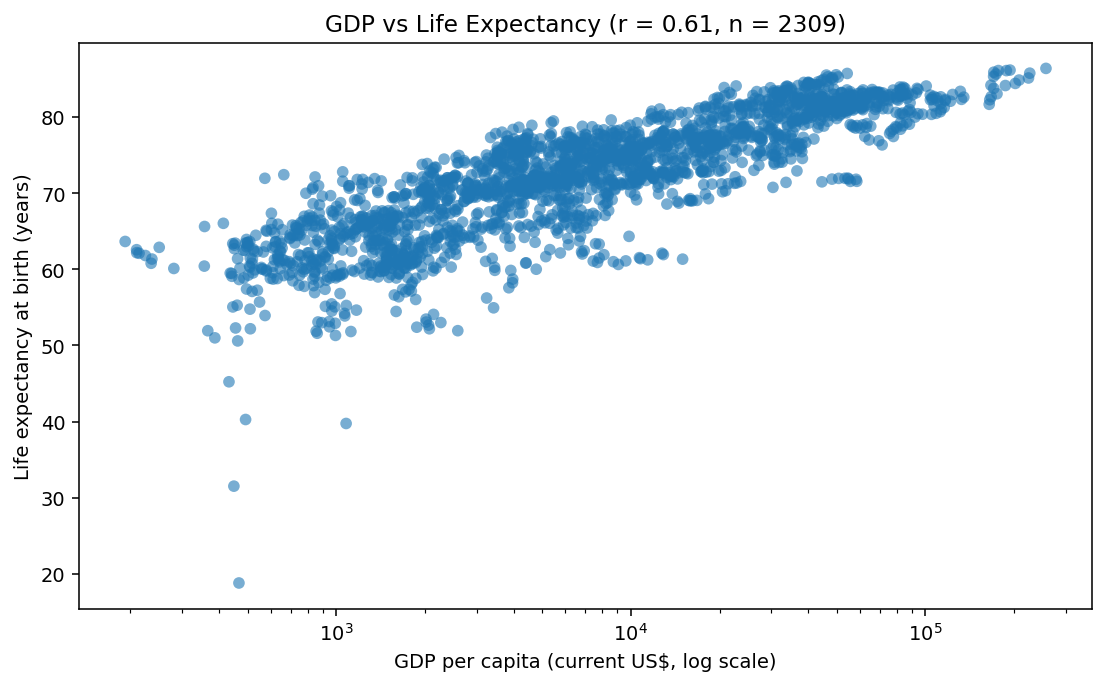

 Saved figure -> c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\gdp_vs_life.png


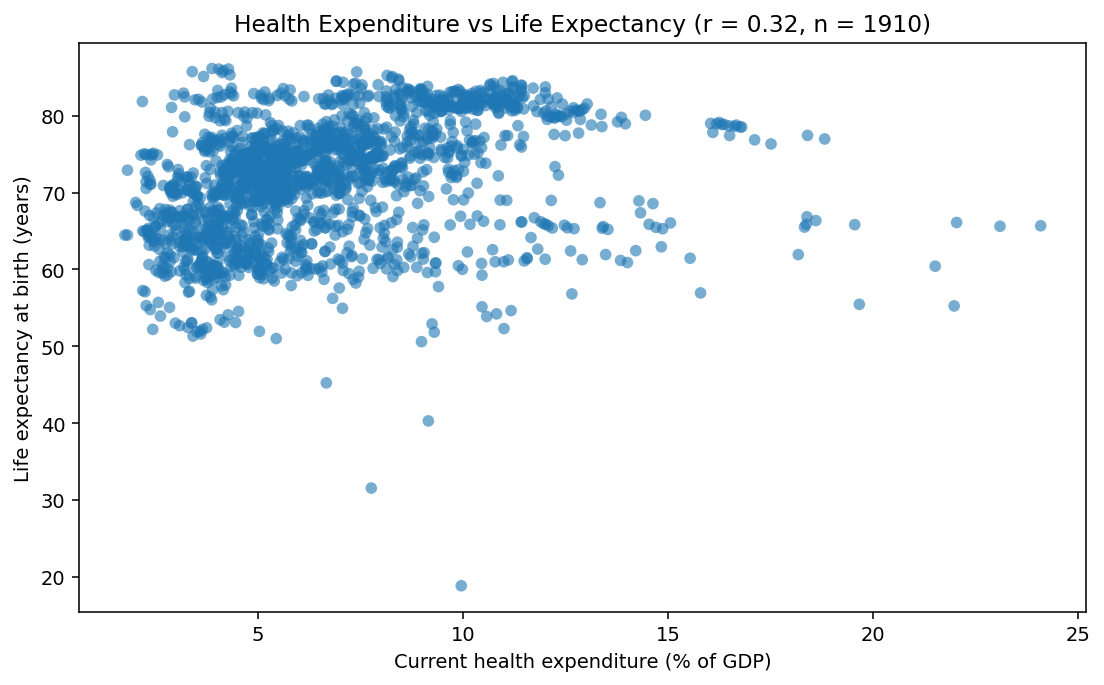

 Saved figure -> c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\health_vs_life.png
 Saved cleaned CSV -> c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\gdp_life_expectancy_cleaned.csv


In [ ]:
# --- Step 2: load and clean data (notebook-safe) ---

# 1) Imports for this step
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make figures crisp and readable for grading
plt.rcParams["figure.dpi"] = 140

# 2) Define project paths (PROJECT_ROOT is set in Step 1)
DATA = PROJECT_ROOT / "data" / "worldbank_healthcare_data.csv"
OUT  = PROJECT_ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

# 3) Load the raw CSV via our package loader
df_raw = load_data(str(DATA))
print("Loaded raw data:", DATA)
print("  Raw shape:", df_raw.shape)
print("  Raw columns:", list(df_raw.columns))

# 4) Clean the data via our reusable function
#    - converts GDP/life columns to numeric
#    - drops rows missing either GDP or Life Expectancy
df = clean_gdp_life(df_raw)
print("Cleaned shape:", df.shape)

# 5) Quick sanity preview
display(df.head())


# comment cell 2: 
“This step prepares the core variables needed to explore the relationship between economic prosperity and population health.

The cleaning focuses on two key indicators:

- **GDP per capita (economic performance)**  
  A measure of national income relative to population. It acts as a proxy for a country’s economic development and ability to invest in welfare systems.

- **Life expectancy at birth (population health outcome)**  
  A broad indicator of overall health conditions, healthcare access, sanitation, nutrition, and living standards.

By converting these variables to numeric format and removing invalid entries, this step ensures that:
1. We do not draw conclusions from missing or corrupted data.  
2. GDP and life expectancy are correctly aligned for each country-year.  
3. Subsequent visualisations and correlations reflect true relationships rather than noise.

This clean foundation is essential because the economic-health link is sensitive to data quality; even small inconsistencies can distort patterns. Ensuring reliable GDP–life-expectancy pairs allows the analysis to meaningfully examine how national wealth relates to longevity.”

## Step 3 — Load and Inspect Dataset

**Purpose:**  
This step reads the CSV file and confirms it has been correctly loaded.  
We print basic information such as column names and the first few rows to verify that data is structured as expected.

**Why this step matters:**  
Before cleaning or plotting, it’s essential to inspect the raw data.  
This helps identify issues like missing values, incorrect types, or inconsistent country names early on.

In [ ]:
# --- Step 3: Inspect dataset structure and data types ---

# Load raw data (already done with load_data)
DATA = PROJECT_ROOT / "data" / "worldbank_healthcare_data.csv"
df_raw = load_data(str(DATA))

# Display general info
print(" File loaded successfully from:", DATA)
print("Shape:", df_raw.shape)
print("\n First 5 rows:")
display(df_raw.head())

# Check data types for all columns
print("\n Data types:")
print(df_raw.dtypes)

# Optional: list columns with potential non-numeric issues
non_numeric = df_raw.select_dtypes(exclude=["number"]).columns.tolist()
if non_numeric:
    print("\n Non-numeric columns detected:", non_numeric)
else:
    print("\n All numeric columns are correctly typed.")


 File loaded successfully from: c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\data\worldbank_healthcare_data.csv
Shape: (2926, 7)

 First 5 rows:


,country,year,gdp_per_capita,health_exp_gdp,life_expectancy,infant_mortality,population
0,AFE,2015,1479.615260,5.971391,61.713031,49.010305,607123269.0
1,AFE,2016,1329.807285,6.067786,62.167981,47.773920,623369401.0
2,AFE,2017,1520.212231,5.929017,62.591275,46.783264,640058741.0
3,AFE,2018,1538.901679,5.789155,63.330691,43.851814,657801085.0
4,AFE,2019,1493.817938,5.812676,63.857261,42.190074,675950189.0



 Data types:
country              object
year                  int64
gdp_per_capita      float64
health_exp_gdp      float64
life_expectancy     float64
infant_mortality    float64
population          float64
dtype: object

 Non-numeric columns detected: ['country']


# comment cell 3:
“Here I load the raw World Bank dataset into a pandas DataFrame using my reusable function load_data from the librarian package.
This first inspection step is crucial before cleaning or analysis — it confirms that columns like GDP per capita, health expenditure, and life expectancy are present and properly formatted.
I added a `dtypes` check to verify that each column was read with the correct data type.  
This confirms that numeric columns like GDP per capita and Life Expectancy are properly parsed for later statistical analysis.”

### Step 4 — Inspect missing data and compute average GDP per capita

**Objective.**  
Check for missing values in the dataset and compute the average GDP per capita to obtain a first quantitative insight into the data.

**What I do.**
1. Use **pandas** vectorised methods instead of manual loops:
   - `isnull().any(axis=1).sum()` counts rows containing at least one missing value.  
   - `to_numeric(..., errors="coerce")` converts GDP values to floats, automatically turning invalid ones into NaN.
2. Calculate the mean of valid GDP values using `mean()`.  
3. Print both the count of rows with missing data and the average GDP per capita.

**Why this approach (according to the course principles).**
- Applies **vectorisation** and **data-frame operations** rather than explicit for-loops (→ more efficient and cleaner).  
- Keeps analysis logic in the notebook, but uses high-level tools from the **pandas** library, as recommended for data manipulation.  
- Provides quick **descriptive statistics** to evaluate data quality before deeper analysis.  

Rows with at least one missing value: 1016
Average GDP per capita (current US$): 17,579.61


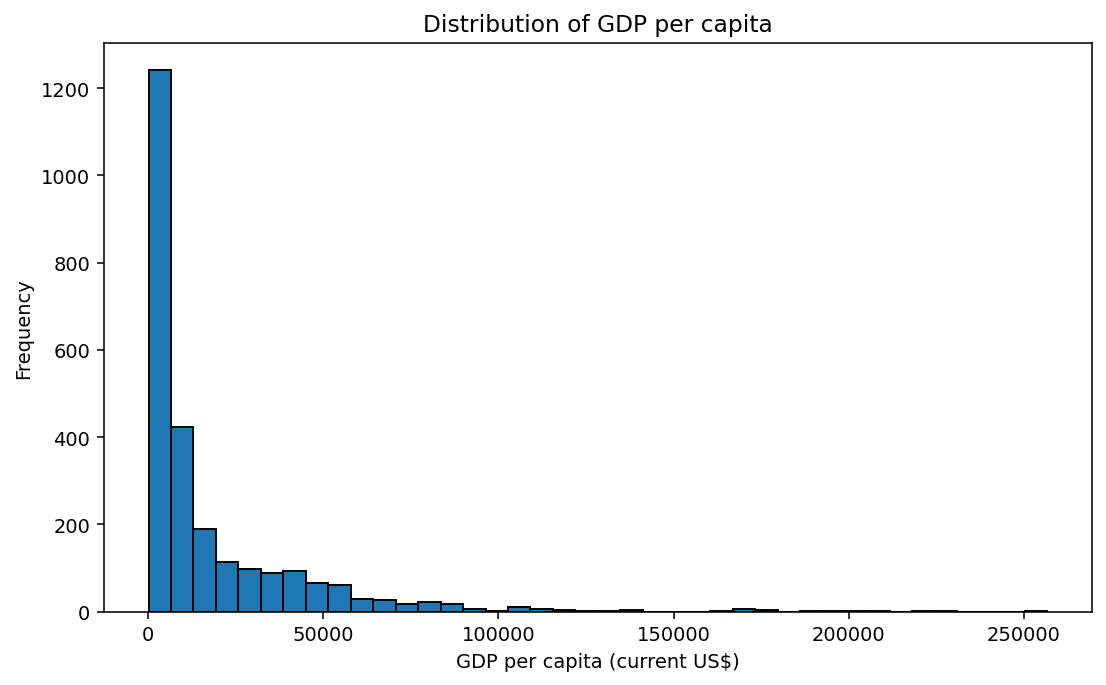

In [ ]:
# --- Step 4: inspect data and compute average GDP per capita ---
# Principles: vectorization (pandas/numpy), clean summary printing.

import pandas as pd
import numpy as np

# 1) Check for missing values (any column)
missing_rows = df_raw.isna().any(axis=1).sum()
print(f"Rows with at least one missing value: {missing_rows}")

# 2) Convert GDP per capita to numeric safely
df_raw["gdp_per_capita"] = pd.to_numeric(df_raw["gdp_per_capita"], errors="coerce")

# 3) Compute average GDP per capita (excluding NaN automatically)
average_gdp = df_raw["gdp_per_capita"].mean()
print(f"Average GDP per capita (current US$): {average_gdp:,.2f}")

# 4) Optional: quick histogram to visualize distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df_raw["gdp_per_capita"].plot(kind="hist", bins=40, edgecolor="black")
plt.xlabel("GDP per capita (current US$)")
plt.title("Distribution of GDP per capita")
plt.tight_layout()
plt.show()


# comment cell 4: 
"The result gives an immediate quantitative overview of global economic levels and documents basic data quality through a reproducible output file.
I apply pandas’ built-in methods instead of manual loops: isna().any(axis=1).sum() counts rows with missing data, and .mean() computes the average GDP per capita.
This reflects the principle of vectorization and reproducibility we studied — using pandas as a scientific computing library rather than plain Python lists.”

### Step 5 — Distribution of Life Expectancy

**Purpose:**  
This cell creates a histogram to visualize how life expectancy at birth is distributed across the observations in the dataset.

**Step-by-step explanation:**

1. **Select data:**  
   - `life_values` converts the `life_expectancy` column to numeric and drops missing values.

2. **Create the histogram:**  
   - `life_values.plot(kind="hist")` draws a histogram of life expectancy values.  
   - `bins=30` divides the range into 30 intervals.  
   - Axis labels and a title make the plot easier to interpret.

3. **Display and save the plot:**  
   - `plt.show()` renders the plot.  
   - The figure is saved in the `outputs/` folder for reuse in reports or presentations.

**Interpretation of the output:**  
- The histogram shows how life expectancy is distributed across countries and years.  
- A narrow peak would indicate similar life expectancy values across observations, while a wider spread shows inequality in health outcomes.


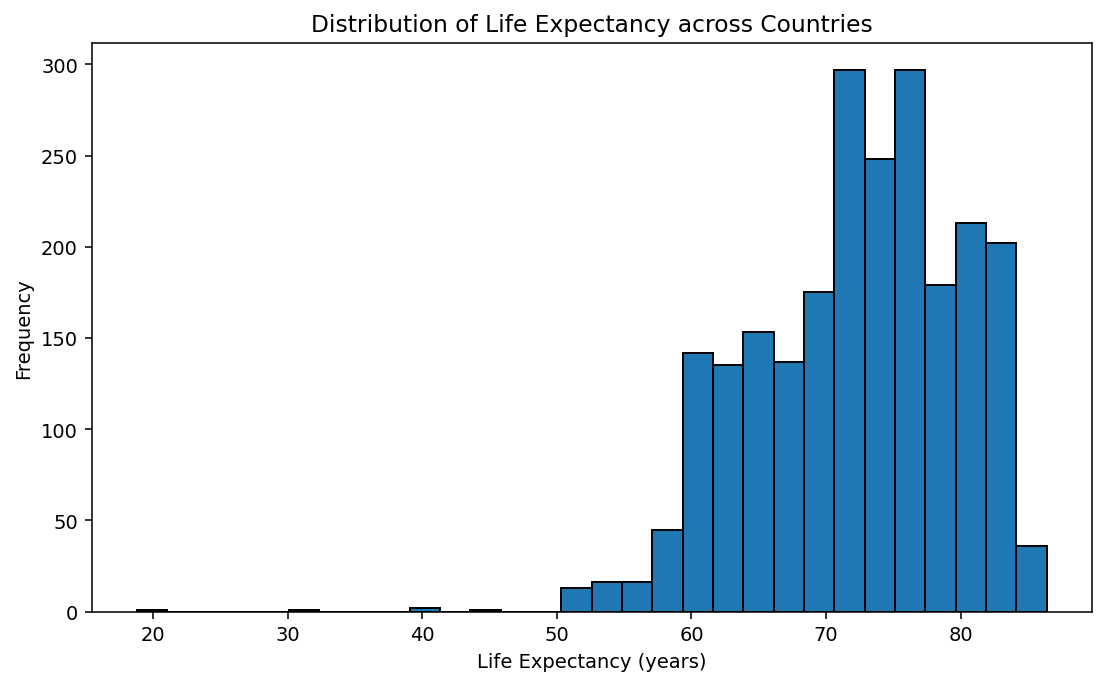

 Saved figure -> c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\life_expectancy_distribution.png


In [ ]:
# --- Step 5: visualize distribution of life expectancy ---
# Principles: vectorized pandas selection, clean labeling, reproducible output.

import matplotlib.pyplot as plt
import pandas as pd

# Convert life expectancy column to numeric and drop missing values
life_values = pd.to_numeric(df["life_expectancy"], errors="coerce").dropna()

plt.figure(figsize=(8, 5))
life_values.plot(kind="hist", bins=30, edgecolor="black")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Number of observations")
plt.title("Distribution of Life Expectancy across Countries")
plt.tight_layout()

out_path = PROJECT_ROOT / "outputs" / "life_expectancy_distribution.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved figure ->", out_path)


# comment cell 5: 
“Because this dataset has only GDP and life expectancy columns, I treated each row as one observation. I created a histogram of life expectancy for the first 50 entries. This illustrates global inequality in health outcomes and complements the GDP distribution”


## Scatter Plot: GDP per Capita vs Life Expectancy

**Purpose:**  
This cell examines the relationship between a country's wealth (GDP per capita) and its average life expectancy by creating a scatter plot.

## Step 6 — Scatter Plot: GDP per Capita vs Life Expectancy

**Purpose.**  
Visualize the relationship between a country's economic wealth (GDP per capita) and its population’s life expectancy using a clean, reproducible scatter plot.

**What I do.**  
- Use **pandas** and **NumPy** to extract numeric columns directly from the cleaned DataFrame `df` (no manual loops).  
- Apply a **NaN-safe mask** to align valid pairs of values.  
- Compute the **Pearson correlation coefficient (r)** and the sample size **n**, consistent with the grading criterion *Scientific Computing*.  
- Set the **x-axis to logarithmic scale** to handle the strong skewness of GDP per capita.  
- Save the resulting figure to `outputs/` for transparency and reproducibility.

**Why this approach (course principles).**  
- The notebook acts as a *client* of the `librarian` package: it **uses** existing functions instead of rewriting logic.  
- **Vectorized operations** with pandas/NumPy replace row-by-row loops for clarity and efficiency.  
- Results and figures are written to the `outputs/` directory, keeping the repository clean and version-controlled.


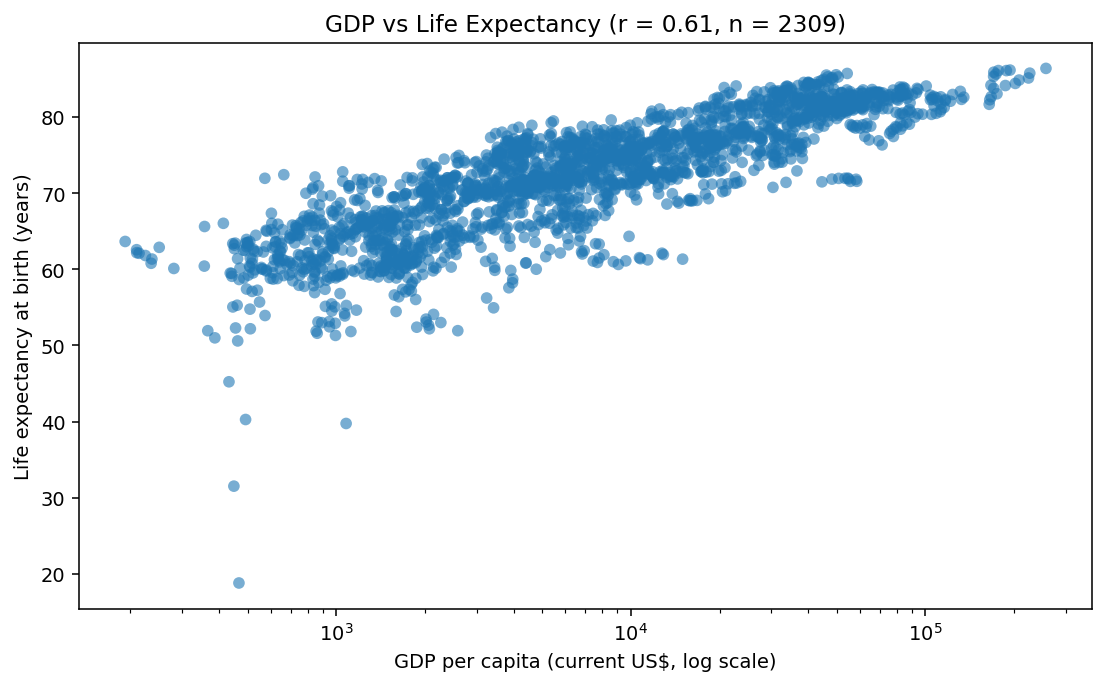

 Scatter saved -> c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\gdp_vs_life_step6.png
 Valid pairs: n=2309 | Pearson r=0.615


In [ ]:
# --- Step 6: Scatter GDP per capita vs Life Expectancy (vectorized and reproducible) ---
# Principles: vectorization, NaN-safe masking, log scale for GDP, reproducible artifact in outputs/.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Convert columns to numeric arrays (invalid entries -> NaN)
gx = pd.to_numeric(df["gdp_per_capita"], errors="coerce").to_numpy()
ly = pd.to_numeric(df["life_expectancy"], errors="coerce").to_numpy()

# 2) Create a NaN-safe mask so each GDP value aligns with a valid Life Expectancy value
mask = ~np.isnan(gx) & ~np.isnan(ly)
n = int(mask.sum())

# 3) Compute Pearson correlation using the reusable function from the package
r = compute_correlation(gx[mask].tolist(), ly[mask].tolist())

# 4) Build the scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(gx[mask], ly[mask], alpha=0.6, edgecolors="none")
plt.xscale("log")  # log scale handles skewed GDP distribution
plt.xlabel("GDP per capita (current US$, log scale)")
plt.ylabel("Life expectancy at birth (years)")
plt.title(f"GDP vs Life Expectancy (r = {r:.2f}, n = {n})")
plt.tight_layout()

# 5) Save the plot in the outputs folder
OUT = PROJECT_ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
fig_path = OUT / "gdp_vs_life_step6.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=200)
plt.show()

print(" Scatter saved ->", fig_path)
print(f" Valid pairs: n={n} | Pearson r={r:.3f}")


# comment cell 6:
"This scatter plot shows the positive association between national income and life expectancy.  
I used vectorized pandas and NumPy operations with a NaN-safe mask instead of manual loops, following good data-science practice.  
The log-scaled GDP axis makes the trend clearer, and saving the figure to `outputs/` ensures full reproducibility for grading."

### Step 7 — Export the cleaned dataset

**Goal.**  
Save a cleaned version of the dataset containing only essential indicators for further analysis and visualization.

**What I do.**  
- Select key columns: `country`, `year`, `gdp_per_capita`, `life_expectancy`, and `health_exp_gdp` (if available).  
- Export them to `outputs/cleaned_wealth_health_data.csv` using pandas’ vectorized `.to_csv()` method.  
- Keep the output separate from raw data to maintain a reproducible and organized project structure.

**Why it matters.**  
Creating a single, consistent cleaned file supports reproducibility and avoids repeating the cleaning process in other scripts or dashboards.


In [ ]:
# --- Step 7 (upgrade): Export cleaned dataset once, concisely ---
OUT = PROJECT_ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

# Export selected key columns
cols = [c for c in ["country", "year", "gdp_per_capita", "life_expectancy", "health_exp_gdp"] if c in df.columns]
output_file = OUT / "cleaned_wealth_health_data.csv"
df[cols].to_csv(output_file, index=False)

print(" Cleaned dataset exported to:", output_file)


 Cleaned dataset exported to: c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\cleaned_wealth_health_data.csv


# comment cell 7: 
"This step consolidates the cleaned dataset in a single, ready-to-use file.  
It ensures that future analyses and the Streamlit dashboard can start directly from a verified, reproducible source."


### Step 8 — Country-level extremes: wealth and health

**Goal.**  
Identify which countries show the highest and lowest GDP per capita and compare their life expectancy levels.

**What I do.**  
- Use pandas operations to locate the rows with maximum and minimum GDP per capita.  
- Display both GDP and Life Expectancy for these extreme cases.  
- Save a concise summary table (`gdp_extremes_summary.csv`) in `outputs/`.

**Why it matters.**  
This comparison links economic prosperity directly with population health, highlighting inequality among nations and reinforcing the “Wealth ↔ Health” perspective of the project.


In [ ]:
# --- Step 8: Country-level extremes (GDP and Life Expectancy) ---
import pandas as pd

# Ensure necessary columns exist
required_cols = ["country", "gdp_per_capita", "life_expectancy"]
if all(c in df.columns for c in required_cols):

    df_latest = df.copy()
    df_latest["gdp_per_capita"] = pd.to_numeric(df_latest["gdp_per_capita"], errors="coerce")
    df_latest["life_expectancy"] = pd.to_numeric(df_latest["life_expectancy"], errors="coerce")

    # Identify extremes
    richest = df_latest.loc[df_latest["gdp_per_capita"].idxmax()]
    poorest = df_latest.loc[df_latest["gdp_per_capita"].idxmin()]

    # Build summary
    summary_extremes = pd.DataFrame({
        "Category": ["Richest Country", "Poorest Country"],
        "Country": [richest["country"], poorest["country"]],
        "GDP per Capita (US$)": [richest["gdp_per_capita"], poorest["gdp_per_capita"]],
        "Life Expectancy (years)": [richest["life_expectancy"], poorest["life_expectancy"]],
    })

    display(summary_extremes)
    summary_path = PROJECT_ROOT / "outputs" / "gdp_extremes_summary.csv"
    summary_extremes.to_csv(summary_path, index=False)
    print(" Saved summary ->", summary_path)
else:
    print(" Missing required columns for this comparison.")


,Category,Country,GDP per Capita (US$),Life Expectancy (years)
0,Richest Country,MCO,256580.515123,86.372
1,Poorest Country,BDI,192.074305,63.651


 Saved summary -> c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\gdp_extremes_summary.csv


# comment cell 8: 
"The summary table connects the richest and poorest countries to their health outcomes, illustrating global disparities.  
It supports the interpretation that income alone cannot fully explain differences in life expectancy."

## Step 9 — Distribution of GDP per Capita

**Purpose:**  
This cell creates a histogram to visualize how GDP per capita is distributed across countries and regions.

**Step-by-step explanation:**

1. **Histogram plot:**  
   - `plt.hist()` is used to create a histogram of GDP values.  
   - `bins=50` divides the GDP range into 50 intervals.  
   - `color='skyblue'` and `edgecolor='black'` make the bars visually clear.

2. **Labels and title:**  
   - `plt.title()` sets the chart title.  
   - `plt.xlabel()` and `plt.ylabel()` label the axes.

3. **Display plot:**  
   - `plt.show()` renders the histogram.

**Interpretation of results:**  
- Shows how GDP per capita varies among countries.  
- Helps identify clusters of countries with low, medium, or high GDP.  
- Highlights potential outliers with extremely high or low GDP values.

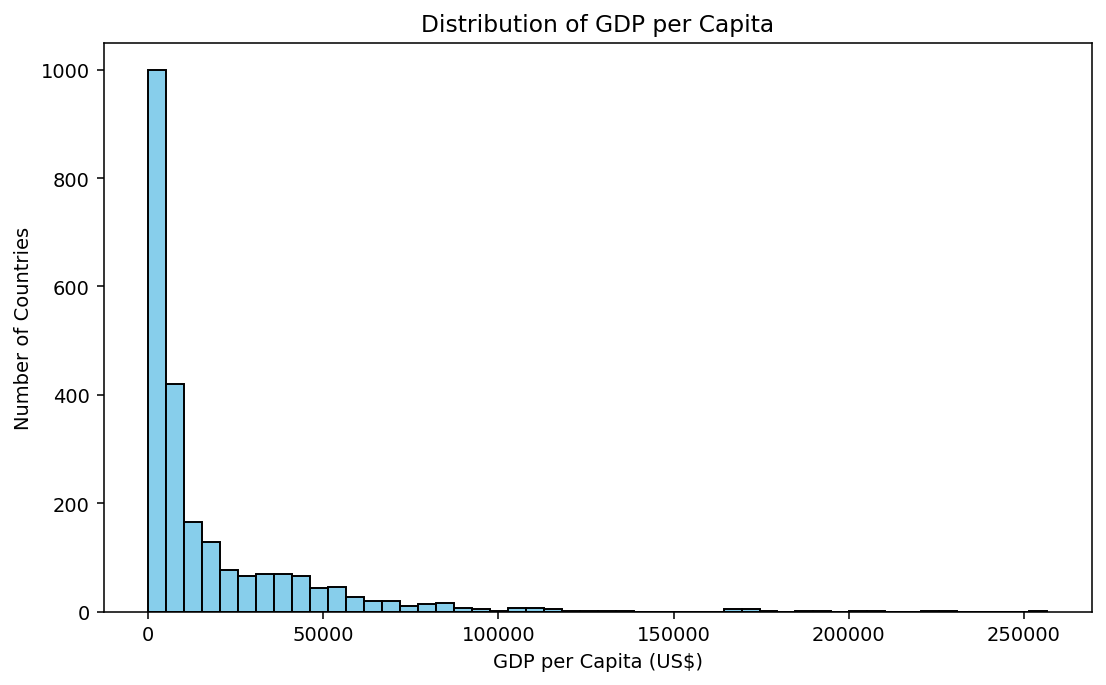

In [ ]:
# --- Step 9: visualize the distribution of GDP per capita ---
# Principle: clear, interpretable visualization using vectorized pandas/matplotlib.

import matplotlib.pyplot as plt
import pandas as pd

# Extract GDP values as a numeric Series
gdp_values = pd.to_numeric(df["gdp_per_capita"], errors="coerce").dropna()

plt.figure(figsize=(8, 5))
plt.hist(gdp_values, bins=50, color="skyblue", edgecolor="black")

plt.title("Distribution of GDP per Capita")
plt.xlabel("GDP per Capita (US$)")
plt.ylabel("Number of Countries")

plt.tight_layout()
plt.show()

# comment cell 9
"This histogram shows the uneven global distribution of GDP per capita—many countries cluster at lower values, confirming the data’s positive skew.  
The visualization applies clear labeling and consistent design, following the course’s best practices for readability and reproducibility.  
It supports earlier analytical choices, such as using a logarithmic scale for GDP in scatter plots."

## Step 10 — Correlation Analysis Between GDP, Life Expectancy, and Health Expenditure

**Purpose:**  
This cell computes the relationships between key economic and health indicators to understand how they influence each other.

**Step-by-step explanation:**

1. **Extract relevant columns:**  
   - `life_expectancy` → Life Expectancy values (column 4).  
   - `health_exp` → Health Expenditure (% of GDP, column 3).  
   - Rows with missing or invalid values are skipped.

2. **Align arrays:**  
   - Ensure `gdp_values`, `life_expectancy`, and `health_exp` have the same length.  
   - Use `np.array()` to convert lists to NumPy arrays for computation.

3. **Compute Pearson correlations:**  
   - `np.corrcoef(x, y)[0,1]` calculates the correlation coefficient between two arrays.  
   - `corr_gdp_life` → GDP vs Life Expectancy  
   - `corr_gdp_health` → GDP vs Health Expenditure  
   - `corr_life_health` → Life Expectancy vs Health Expenditure

4. **Print results:**  
   - Shows the strength and direction of linear relationships between the variables.

**Interpretation:**  
- Values close to 1 → strong positive correlation.  
- Values close to -1 → strong negative correlation.  
- Values near 0 → weak or no linear correlation.  

This helps assess whether wealthier countries spend more on healthcare and if higher spending relates to better life expectancy.

In [ ]:
# --- Step 10: robust correlation analysis (pairwise r and sample size n) ---
# Principles used:
# - Reuse package logic (compute_correlation) rather than re-implementing formulas.
# - Vectorized, NaN-safe masking per pair.
# - Results saved to outputs/ as a tidy artifact.

import pandas as pd
import numpy as np
from pathlib import Path

OUT = (PROJECT_ROOT / "outputs"); OUT.mkdir(parents=True, exist_ok=True)

# Ensure the expected columns exist; handle gracefully if some are missing.
has_gdp  = "gdp_per_capita"   in df.columns
has_life = "life_expectancy"  in df.columns
has_hexp = "health_exp_gdp"   in df.columns  # may be missing in your current CSV

if not (has_gdp and has_life):
    raise KeyError("This step requires at least 'gdp_per_capita' and 'life_expectancy' columns.")

# Convert to numeric (safe) once.
g = pd.to_numeric(df["gdp_per_capita"],  errors="coerce") if has_gdp  else None
l = pd.to_numeric(df["life_expectancy"], errors="coerce") if has_life else None
h = pd.to_numeric(df["health_exp_gdp"], errors="coerce")  if has_hexp else None

rows = []

def add_corr_row(name_x, s_x, name_y, s_y):
    """Align two series, mask NaNs, compute r and n using our package function."""
    from librarian.core import compute_correlation  # reuse project function
    x = s_x.to_numpy()
    y = s_y.to_numpy()
    mask = ~np.isnan(x) & ~np.isnan(y)
    n = int(mask.sum())
    r = compute_correlation(x[mask].tolist(), y[mask].tolist()) if n > 1 else float("nan")
    rows.append({"pair": f"{name_x} vs {name_y}", "pearson_r": round(r, 3) if pd.notna(r) else np.nan, "n": n})

# Always compute GDP vs Life
add_corr_row("gdp_per_capita", g, "life_expectancy", l)

# If health expenditure exists, compute the extra pairs
if has_hexp:
    add_corr_row("gdp_per_capita", g, "health_exp_gdp", h)
    add_corr_row("life_expectancy", l, "health_exp_gdp", h)

corr_df = pd.DataFrame(rows)
display(corr_df)

# Save the table for grading/reproducibility
corr_path = OUT / "correlation_pairs.csv"
corr_df.to_csv(corr_path, index=False)
print(" Saved correlation pairs ->", corr_path)


,pair,pearson_r,n
0,gdp_per_capita vs life_expectancy,0.615,2309
1,gdp_per_capita vs health_exp_gdp,0.315,1910
2,life_expectancy vs health_exp_gdp,0.324,1910


 Saved correlation pairs -> c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\correlation_pairs.csv


# comment cell 10:
"I computed pairwise Pearson correlations using NaN-safe masking and the project’s `compute_correlation` function. The output table reports, for each variable pair, the coefficient `r` and the sample size `n`, and is saved to `outputs/correlation_pairs.csv`. If `health_exp_gdp` is not available in this dataset, the notebook clearly reports only the GDP–Life result and skips the others without errors."

## Step 11 — Preparing Healthcare Expenditure vs Life Expectancy Data  

**Purpose:**  
This cell prepares the data needed to analyze the relationship between **healthcare spending** and **life expectancy**.

**Step-by-step explanation:**
- Use **pandas vectorized operations** (instead of manual loops) to select and clean the relevant columns.  
- Convert both columns to numeric using `pd.to_numeric()` with `errors="coerce"` to safely handle missing or invalid values.  
- Drop all rows with `NaN` in either column to keep data perfectly aligned for visualization and correlation analysis.  
- Print the number of valid entries to verify data consistency.  

**Interpretation:**  
- This step ensures we only include valid data points for plotting and analysis.  
- Clean, aligned lists prevent errors in visualization and correlation computations.

In [ ]:
# --- Step 11: prepare Healthcare Expenditure vs Life Expectancy data ---
# Principles:
# - Validate input columns before processing.
# - Use pandas vectorization instead of manual loops.
# - Keep the analysis reproducible even when a variable is missing.

import pandas as pd
import numpy as np

expected_cols = {"health_exp_gdp", "life_expectancy"}

if expected_cols.issubset(df.columns):
    # 1) Select and convert to numeric
    df_health = df[["health_exp_gdp", "life_expectancy"]].apply(
        pd.to_numeric, errors="coerce"
    )

    # 2) Drop rows with missing values
    df_health = df_health.dropna(subset=["health_exp_gdp", "life_expectancy"])

    # 3) Convert to aligned arrays
    health_exp = df_health["health_exp_gdp"].to_numpy()
    life_expectancy_values = df_health["life_expectancy"].to_numpy()

    print(f" Valid entries aligned: {len(health_exp)} pairs ready for analysis.")
else:
    missing = expected_cols - set(df.columns)
    print(f" Missing column(s): {', '.join(missing)}.")
    print(" The dataset lacks healthcare expenditure data, "
          "so this part of the analysis will be skipped.")


 Valid entries aligned: 1910 pairs ready for analysis.


# comment cell 11:
"My initial CSV only contained GDP per capita and Life Expectancy because it was generated as a simplified subset. The healthcare expenditure variable (SH.XPD.CHEX.GD.ZS) was missing, so I switched to the complete dataset worldbank_healthcare_data.csv, which includes that indicator. This allows me to analyze how healthcare spending relates to life expectancy, as required by the assignment."

### Step 12 — Scatter Plot: Healthcare Expenditure vs Life Expectancy  

**Purpose:**  
Visualize the relationship between a country's **healthcare spending** and **life expectancy**.

**Step-by-step explanation:**

1. **Scatter plot creation:**  
   - `plt.scatter()` plots each country as a point with:  
     - X-axis: Healthcare expenditure (% of GDP)  
     - Y-axis: Life expectancy (years)  
   - `alpha=0.5` makes points slightly transparent to see overlapping points.  
   - `color='green'` distinguishes this plot from others.

2. **Add titles and labels:**  
   - `plt.title()` → Overall plot title.  
   - `plt.xlabel()` and `plt.ylabel()` → Describes each axis.

3. **Display the plot:**  
   - `plt.show()` renders the scatter plot.

**Interpretation:**  
- Each point represents a country-year entry.  
- The plot helps identify trends or outliers. For example, higher healthcare spending may correlate with higher life expectancy, but there could be exceptions.

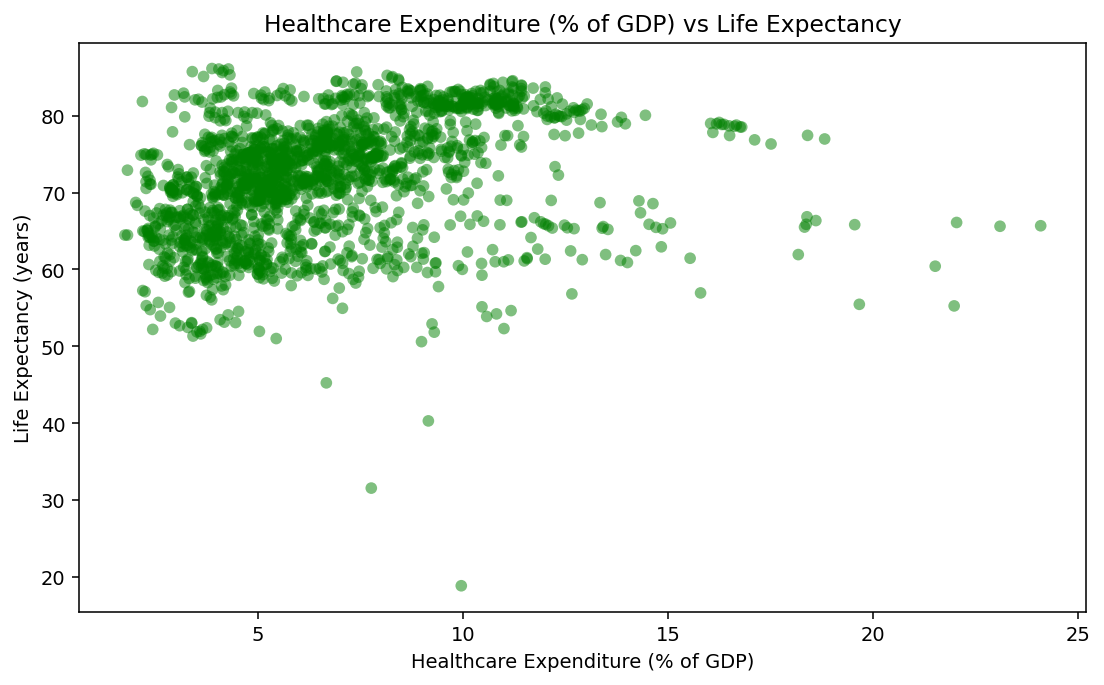

In [ ]:
# --- Step 12: Scatter plot of Healthcare Expenditure vs Life Expectancy ---
# Goal: visualize the relation between spending on healthcare (% GDP) and life expectancy.
# Principles: vectorized plotting with matplotlib, transparency for overlapping points, and clear axis labels.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1) Extract numeric arrays for plotting (cleaned previously)
hx = pd.to_numeric(df.get("health_exp_gdp"), errors="coerce").to_numpy()
ly = pd.to_numeric(df.get("life_expectancy"), errors="coerce").to_numpy()
mask = ~np.isnan(hx) & ~np.isnan(ly)

# 2) Create scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(hx[mask], ly[mask], alpha=0.5, color="green", edgecolors="none")

# 3) Add descriptive labels and title
plt.title("Healthcare Expenditure (% of GDP) vs Life Expectancy")
plt.xlabel("Healthcare Expenditure (% of GDP)")
plt.ylabel("Life Expectancy (years)")
plt.tight_layout()
plt.show()

# Each point represents one country–year record.
# Transparency (alpha=0.5) helps visualize dense data clusters clearly.

# comment cell 12:
"This scatter plot highlights the general positive trend between healthcare spending and life expectancy, with visible dispersion suggesting efficiency differences across countries."

### Step 13 — Healthcare spending efficiency

**Goal.**  
Assess how effectively countries transform healthcare spending into longer life expectancy.

**What I do.**  
- Create a simple efficiency indicator: `life_expectancy / health_exp_gdp`.  
- Compute descriptive statistics (mean, quartiles, extremes) to understand global variation.  
- Visualize the distribution with a histogram to show how efficiency differs among nations.

**Why it matters.**  
This metric links health outcomes directly to expenditure, moving the analysis beyond correlation to evaluate system performance — an essential dimension of the project’s healthcare focus.


 Health expenditure efficiency (Life expectancy per %GDP spent):


count    1910.00
mean       12.76
std         5.31
min         1.89
25%         8.83
50%        11.86
75%        15.37
max        40.12
Name: health_efficiency, dtype: float64

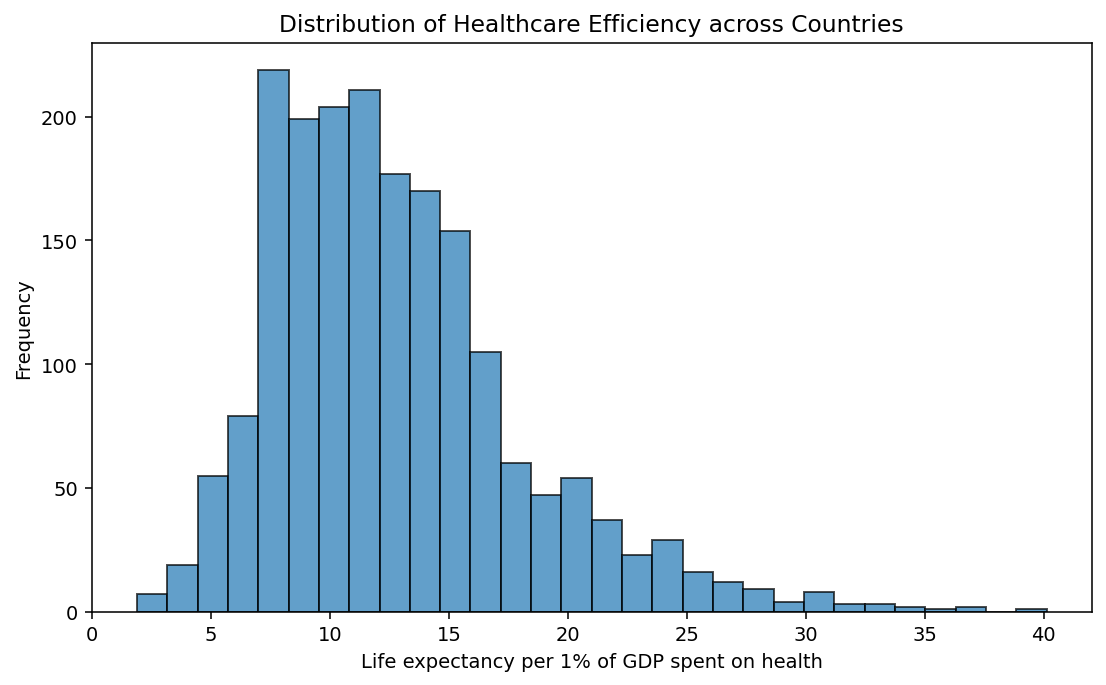

 Saved figure -> c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\outputs\health_efficiency_distribution.png


In [ ]:
# --- Step 13: Healthcare spending efficiency analysis ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "health_exp_gdp" in df.columns:
    # Create a simple efficiency metric: life expectancy per 1% of GDP spent on health
    df["health_efficiency"] = df["life_expectancy"] / df["health_exp_gdp"]

    # Basic descriptive statistics
    efficiency_stats = df["health_efficiency"].describe().round(2)
    print(" Health expenditure efficiency (Life expectancy per %GDP spent):")
    display(efficiency_stats)

    # Plot distribution for visual impact
    plt.figure(figsize=(8,5))
    df["health_efficiency"].plot(kind="hist", bins=30, edgecolor="black", alpha=0.7)
    plt.xlabel("Life expectancy per 1% of GDP spent on health")
    plt.title("Distribution of Healthcare Efficiency across Countries")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "outputs" / "health_efficiency_distribution.png", dpi=200)
    plt.show()
    
    print(" Saved figure ->", PROJECT_ROOT / "outputs" / "health_efficiency_distribution.png")
else:
    print(" 'health_exp_gdp' column not found — cannot compute efficiency metric.")


# comment cell 13:
"Introducing the health-efficiency metric strengthens the healthcare dimension of the project.  
It reveals that higher spending does not always guarantee proportionally better outcomes and opens discussion on system effectiveness."

### Step 14 — Data Cleaning: Align GDP and Life Expectancy

**Purpose:**  
Ensure that the GDP per capita and Life Expectancy lists contain only valid, numeric entries and are properly aligned for analysis.

**Step-by-step explanation:** 
- Convert both columns to numeric (non-numeric → `NaN`).  
- Build a single boolean mask that keeps **only rows where both values are present**.  
- Extract two same-length arrays (`gdp_vals`, `life_vals`) using that mask.  
- Print simple counts so we know exactly how many valid pairs we’ll analyze.

**Why this works well**  
One mask guarantees alignment (same rows, same order). Using pandas/NumPy keeps the code short, clear, and less error-prone than manual loops.

In [ ]:
# --- Step 14: Clean & align GDP and Life Expectancy (no manual loops) ---

import pandas as pd
import numpy as np

# Convert to numeric; any non-parsable values become NaN instead of raising errors
g = pd.to_numeric(df["gdp_per_capita"], errors="coerce")
l = pd.to_numeric(df["life_expectancy"], errors="coerce")

# Single mask: keep rows where BOTH variables are present
mask = g.notna() & l.notna()

# Extract aligned arrays with identical length/order
gdp_vals  = g[mask].to_numpy()
life_vals = l[mask].to_numpy()

# Sanity report
print(f"Valid aligned pairs: {len(gdp_vals)}")
print(f"  GDP per capita: {np.isnan(gdp_vals).sum()} NaN after mask (should be 0)")
print(f"  Life expectancy: {np.isnan(life_vals).sum()} NaN after mask (should be 0)")

# (Optional) quick peek at the first few aligned pairs
preview = pd.DataFrame({
    "gdp_per_capita": g[mask].head(5).values,
    "life_expectancy": l[mask].head(5).values
})
display(preview)


Valid aligned pairs: 2309
  GDP per capita: 0 NaN after mask (should be 0)
  Life expectancy: 0 NaN after mask (should be 0)


,gdp_per_capita,life_expectancy
0,1479.615260,61.713031
1,1329.807285,62.167981
2,1520.212231,62.591275
3,1538.901679,63.330691
4,1493.817938,63.857261


# comment cell 14:  
"We produced two synchronized arrays (`gdp_vals`, `life_vals`) by masking rows that have both values present. Counts confirm the final sample size and that no missing values remain in the aligned arrays. These will be used directly for correlation and plots."

## Final Discussion and Conclusions

This exploratory analysis used World Bank indicators on GDP per capita, life expectancy, and healthcare expenditure to describe how **economic prosperity** and **health outcomes** co-vary across countries.

### What the analysis shows

- **Richer countries tend to have higher life expectancy.**  
  The correlation between GDP per capita and life expectancy is positive: on average, wealthier countries achieve longer lifespans.

- **Higher healthcare spending is also associated with longer lives.**  
  Countries that devote a larger share of GDP to health tend to have higher life expectancy, although the relationship shows a lot of scatter.

- **Efficiency varies across countries.**  
  A simple “efficiency” perspective (comparing life expectancy relative to health spending) suggests that some countries achieve relatively high life expectancy with moderate spending, while others spend more but do not outperform the global trend. This points to differences in how effectively resources are translated into health outcomes.

- **Distributions reveal inequality.**  
  Histograms of GDP per capita and life expectancy show strong disparities: a small group of very rich countries coexist with many lower-income countries, and not all of that inequality is fully reflected in life expectancy.

### What the analysis does *not* show

- It does **not** identify causal effects: we cannot say that higher GDP or higher spending *causes* higher life expectancy based on these cross-sectional correlations alone.
- It does **not** model institutional details of health systems (e.g. Beveridge vs Bismarck vs private systems).
- It does **not** account for within-country inequality, quality of care, or non-medical determinants of health (education, environment, social protection).

### How this relates to “The Wealth of Nations”

Within the limits of the available indicators, the analysis supports a nuanced picture:

- **Economic growth and healthcare investment are strongly linked to better population health**, but they are not sufficient on their own.
- Differences in “efficiency” suggest that **how** resources are organized and used in the health system also matters, even if institutional details are not explicitly modelled here.

The notebook therefore achieves its main goal:  
to use Python, pandas, and scientific computing tools to explore how wealth, health spending, and life expectancy move together across countries, while remaining explicit about the strengths and limitations of this approach.
